# Modelo Random Forest

## Paso 1: Importación de Librerías y Carga de Datos

Cargamos las herramientas necesarias y los datos limpios del pipeline.
Se aplica SMOTE **dentro de cada fold** de la validación cruzada para evitar data leakage.


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Cargamos el dataset limpio completo
df = pd.read_csv('../data/processed/nhanes_clean.csv')

# Separamos features y target
target_col = 'target_tipo_ui'
X = df.drop(columns=[target_col])
y = df[target_col]

# Eliminamos variables con data leakage (definen directamente el target)
cols_leaky = ['ui_esfuerzo_presente', 'ui_urgencia_presente']
X = X.drop(columns=cols_leaky)

# Split estratificado 80/20 (mismo que el pipeline original)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print()
print('Distribución en train (sin SMOTE — distribución real):')
print((y_train.value_counts(normalize=True) * 100).round(1))
print()
print('Distribución en test:')
print((y_test.value_counts(normalize=True) * 100).round(1))


X_train: (7259, 21)  |  y_train: (7259,)
X_test:  (1815, 21)   |  y_test:  (1815,)

Distribución en train (sin SMOTE — distribución real):
target_tipo_ui
none      53.5
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64

Distribución en test:
target_tipo_ui
none      53.6
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64


## Eliminación de variables con data leakage

Durante el EDA, el análisis de Cramér's V detectó que dos variables
presentan una asociación perfecta (V = 1.0) con el target `target_tipo_ui`:

- `ui_esfuerzo_presente`
- `ui_urgencia_presente`

Esto ocurre porque estas variables **forman parte del algoritmo clínico
con el que se construyó el propio target**:

| ui_esfuerzo_presente | ui_urgencia_presente | target_tipo_ui |
|---------------------|---------------------|----------------|
| 1 | 0 | stress |
| 0 | 1 | urge |
| 1 | 1 | mixed |
| 0 | 0 | none |

Se eliminan ambas columnas antes de cualquier entrenamiento.


## Paso 2: Modelo Base (Baseline) con CV honesta

Usamos `ImbPipeline` para que el SMOTE se aplique **dentro de cada fold**
de la validación cruzada.

**Flujo dentro de cada fold:**
1. Datos de train del fold (datos reales) → SMOTE → datos balanceados
2. Random Forest entrena con datos balanceados
3. Evalúa sobre el fold de validación (datos reales, sin sintéticos)

Así las métricas de CV reflejan el rendimiento real del modelo.


In [56]:
# Pipeline: SMOTE + Random Forest (SMOTE se aplica solo al train de cada fold)
pipeline_baseline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Validación cruzada estratificada 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline_baseline,
    X_train, y_train,
    cv=skf,
    scoring={
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted'
    },
    n_jobs=-1
)

baseline_f1_macro = cv_results['test_f1_macro'].mean()
baseline_accuracy = cv_results['test_accuracy'].mean()

print('=' * 55)
print('BASELINE — Validación cruzada 5-fold (CV honesta)')
print('=' * 55)
print(f'Accuracy:    {baseline_accuracy:.4f} +/- {cv_results["test_accuracy"].std():.4f}')
print(f'F1-macro:    {baseline_f1_macro:.4f} +/- {cv_results["test_f1_macro"].std():.4f}')
print(f'F1-weighted: {cv_results["test_f1_weighted"].mean():.4f} +/- {cv_results["test_f1_weighted"].std():.4f}')


BASELINE — Validación cruzada 5-fold (CV honesta)
Accuracy:    0.6242 +/- 0.0104
F1-macro:    0.4656 +/- 0.0168
F1-weighted: 0.6005 +/- 0.0133


## Paso 3: Optimización con Optuna


In [57]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(
            **params,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])

    score = cross_validate(pipeline, X_train, y_train, cv=skf, scoring='f1_macro')
    return score['test_score'].mean()

# Creamos el estudio Optuna para maximizar el F1-Macro
study = optuna.create_study(direction='maximize', study_name='RF_Optimization')
study.optimize(rf_objective, n_trials=30)

print(f'Mejor F1-Macro CV: {study.best_value:.4f}')
print('Mejores parámetros:', study.best_params)


Mejor F1-Macro CV: 0.4922
Mejores parámetros: {'n_estimators': 100, 'max_depth': 9, 'min_samples_split': 14, 'max_features': None}


## Paso 4: Comparación Baseline vs Modelo Afinado


In [58]:
# Aplicamos SMOTE al train completo para entrenar los modelos finales
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'Train con SMOTE: {X_train_sm.shape}')

# Baseline
rf_baseline = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train_sm, y_train_sm)
y_pred_baseline = rf_baseline.predict(X_test)
baseline_test_f1 = f1_score(y_test, y_pred_baseline, average='macro')

# Modelo Tuneado con los parámetros de Optuna
best_params = study.best_params
rf_tuned = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train_sm, y_train_sm)
y_pred_tuned = rf_tuned.predict(X_test)
tuned_test_f1 = f1_score(y_test, y_pred_tuned, average='macro')

print()
print('=== RENDIMIENTO EN TEST (datos reales) ===')
print(f'Baseline F1-Macro:     {baseline_test_f1:.4f}')
print(f'Tuneado F1-Macro:      {tuned_test_f1:.4f}')
print(f'Diferencia:            {tuned_test_f1 - baseline_test_f1:.4f}')


Train con SMOTE: (15540, 21)

=== RENDIMIENTO EN TEST (datos reales) ===
Baseline F1-Macro:     0.4348
Tuneado F1-Macro:      0.4471
Diferencia:            0.0123


## Paso 5: Importancia de Variables (Feature Importances)


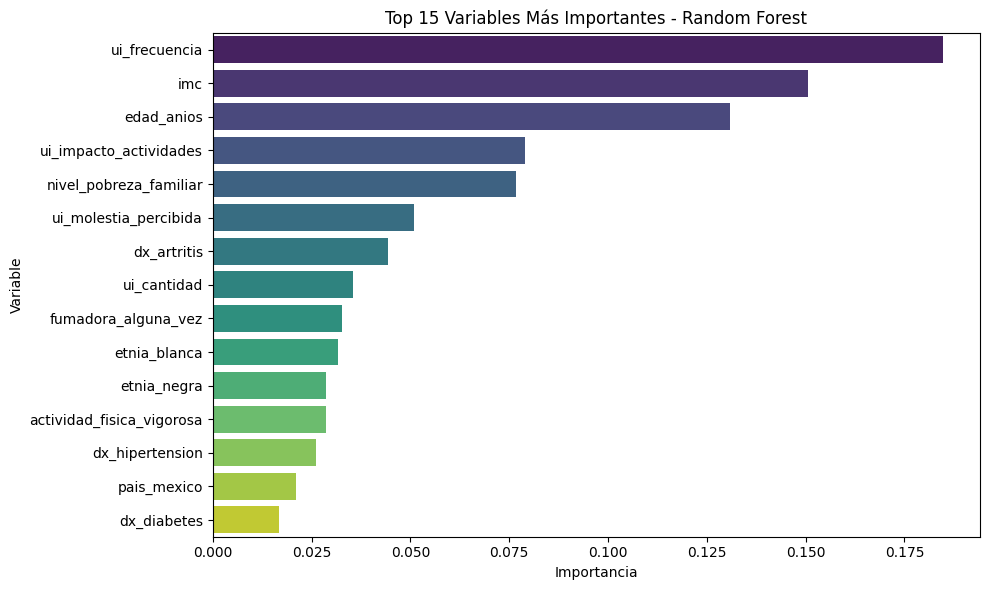

In [59]:
importances = rf_tuned.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Variables Más Importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


## Paso 6: Métricas Finales


In [60]:
# Métricas globales
acc = accuracy_score(y_test, y_pred_tuned)
f1_mac = f1_score(y_test, y_pred_tuned, average='macro')
prec_mac = precision_score(y_test, y_pred_tuned, average='macro')
rec_mac = recall_score(y_test, y_pred_tuned, average='macro')

print('=== MÉTRICAS GLOBALES (Modelo Tuneado) ===')
print(f'Accuracy:        {acc:.4f}')
print(f'F1-Macro:        {f1_mac:.4f}')
print(f'Precision-Macro: {prec_mac:.4f}')
print(f'Recall-Macro:    {rec_mac:.4f}')

print()
print('=== REPORTE POR CLASE ===')
print(classification_report(y_test, y_pred_tuned))

# Overfitting check
y_pred_train = rf_tuned.predict(X_train_sm)
f1_train = f1_score(y_train_sm, y_pred_train, average='macro')
overfit = f1_train - f1_mac
print(f'F1-Macro Train: {f1_train:.4f}')
print(f'F1-Macro Test:  {f1_mac:.4f}')
print(f'Diferencia:     {overfit:.4f} ({overfit*100:.2f}%)')


=== MÉTRICAS GLOBALES (Modelo Tuneado) ===
Accuracy:        0.5967
F1-Macro:        0.4471
Precision-Macro: 0.4485
Recall-Macro:    0.4486

=== REPORTE POR CLASE ===
              precision    recall  f1-score   support

       mixed       0.49      0.54      0.51       328
        none       0.76      0.80      0.78       972
      stress       0.35      0.30      0.32       317
        urge       0.19      0.16      0.17       198

    accuracy                           0.60      1815
   macro avg       0.45      0.45      0.45      1815
weighted avg       0.58      0.60      0.59      1815

F1-Macro Train: 0.6927
F1-Macro Test:  0.4471
Diferencia:     0.2456 (24.56%)


## Paso 7: Guardar Modelo


In [61]:
os.makedirs('../models', exist_ok=True)
joblib.dump(rf_tuned, '../models/random_forest.pkl')
print('Modelo guardado en models/random_forest.pkl')


Modelo guardado en models/random_forest.pkl
